In [4]:
pip install numpy


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
data = pd.read_csv('student_dataset_10000_rows.csv')

In [7]:
df = pd.DataFrame(data)

In [8]:
print(df)

      study_hours  attendance  sleep_hours  internet_usage  \
0               7          56            8               7   
1               4          69            5               3   
2              11          60            7               6   
3               8          99            9               8   
4               5          52            8               6   
...           ...         ...          ...             ...   
9995            2          58            9               7   
9996            7          98            6               9   
9997           10          44            8               5   
9998           10          75            7               5   
9999            2          70            6              11   

      assignments_completed  previous_score  exam_score placement_status  
0                        10              62      100.00           Placed  
1                         8              56      100.00           Placed  
2                        10   

In [9]:
new_df = df.dropna()

In [10]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [11]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [13]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score



In [15]:
X = new_df[['study_hours', 'internet_usage']]

y = new_df['exam_score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ It works now! The model is trained on study hours and internet usage.")

✅ It works now! The model is trained on study hours and internet usage.


In [16]:
y_pred = model.predict(X_test)


print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Error: {mean_absolute_error(y_test, y_pred):.2f} points")

print(f"Study Hours Impact: {model.coef_[0]:.2f}")
print(f"Internet Usage Impact: {model.coef_[1]:.2f}")

R2 Score: 0.3557
Mean Error: 9.42 points
Study Hours Impact: 2.65
Internet Usage Impact: -0.73


In [17]:


X_new = new_df[['study_hours', 'attendance', 'sleep_hours', 'assignments_completed', 'previous_score']]
y_new = new_df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

best_model = LinearRegression()
best_model.fit(X_train, y_train)

y_pred_new = best_model.predict(X_test)

print(f"New R2 Score: {r2_score(y_test, y_pred_new):.4f}")
print(f"New Mean Error: {mean_absolute_error(y_test, y_pred_new):.2f} points")

New R2 Score: 0.6386
New Mean Error: 7.20 points


In [18]:
my_data = pd.DataFrame([{
    'study_hours': 1,
    'attendance': 90,
    'sleep_hours': 7,
    'assignments_completed': 8,
    'previous_score': 70
}])
my_predicted_score = best_model.predict(my_data)
print(f"Predicted Exam Score: {my_predicted_score[0]:.2f}")

Predicted Exam Score: 77.57


In [19]:
for feature, weight in zip(X_new.columns, best_model.coef_):
    print(f"• {feature} -> Impact: {weight:.2f}")

• study_hours -> Impact: 2.65
• attendance -> Impact: 0.20
• sleep_hours -> Impact: 1.27
• assignments_completed -> Impact: 0.97
• previous_score -> Impact: 0.27


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

new_df['placement_status_numeric'] = le.fit_transform(new_df['placement_status'])

print(new_df[['placement_status', 'placement_status_numeric']].head(10))

  placement_status  placement_status_numeric
0           Placed                         1
1           Placed                         1
2           Placed                         1
3           Placed                         1
4           Placed                         1
5           Placed                         1
6           Placed                         1
7           Placed                         1
8           Placed                         1
9           Placed                         1


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = new_df[['study_hours', 'attendance', 'previous_score']]
y = new_df['placement_status_numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_model = LogisticRegression()
class_model.fit(X_train, y_train)

y_pred_class = class_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_class)*100:.2f}%")

Accuracy Score: 85.80%


In [22]:
bad_student = pd.DataFrame([{
    'study_hours': 1,
    'attendance': 40,
    'previous_score': 30
}])

prediction = class_model.predict(bad_student)
probability = class_model.predict_proba(bad_student)

if prediction[0] == 1:
    print("🔮 പ്രവചനം: Placed")
else:
    print("🔮 പ്രവചനം: Not Placed")

print(f"📉 കമ്പ്യൂട്ടറിന്റെ ഉറപ്പ് (Confidence): {probability[0][0]*100:.2f}%")

🔮 പ്രവചനം: Not Placed
📉 കമ്പ്യൂട്ടറിന്റെ ഉറപ്പ് (Confidence): 95.19%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3384 (\N{MALAYALAM LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Malayalam natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3364 (\N{MALAYALAM LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3405 (\N{MALAYALAM SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3375 (\N{MALAYALAM LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python

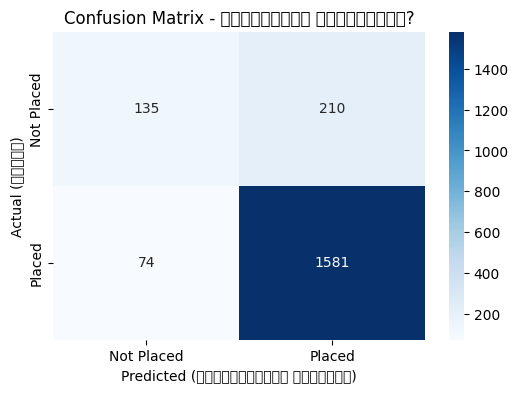

              precision    recall  f1-score   support

           0       0.65      0.39      0.49       345
           1       0.88      0.96      0.92      1655

    accuracy                           0.86      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.84      0.86      0.84      2000



In [23]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted (കമ്പ്യൂട്ടർ പറഞ്ഞത്)')
plt.ylabel('Actual (സത്യം)')
plt.title('Confusion Matrix - എവിടെയാണ് തെറ്റിയത്?')
plt.show()

print(classification_report(y_test, y_pred_class))

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree)*100:.2f}%")

Decision Tree Accuracy: 84.05%


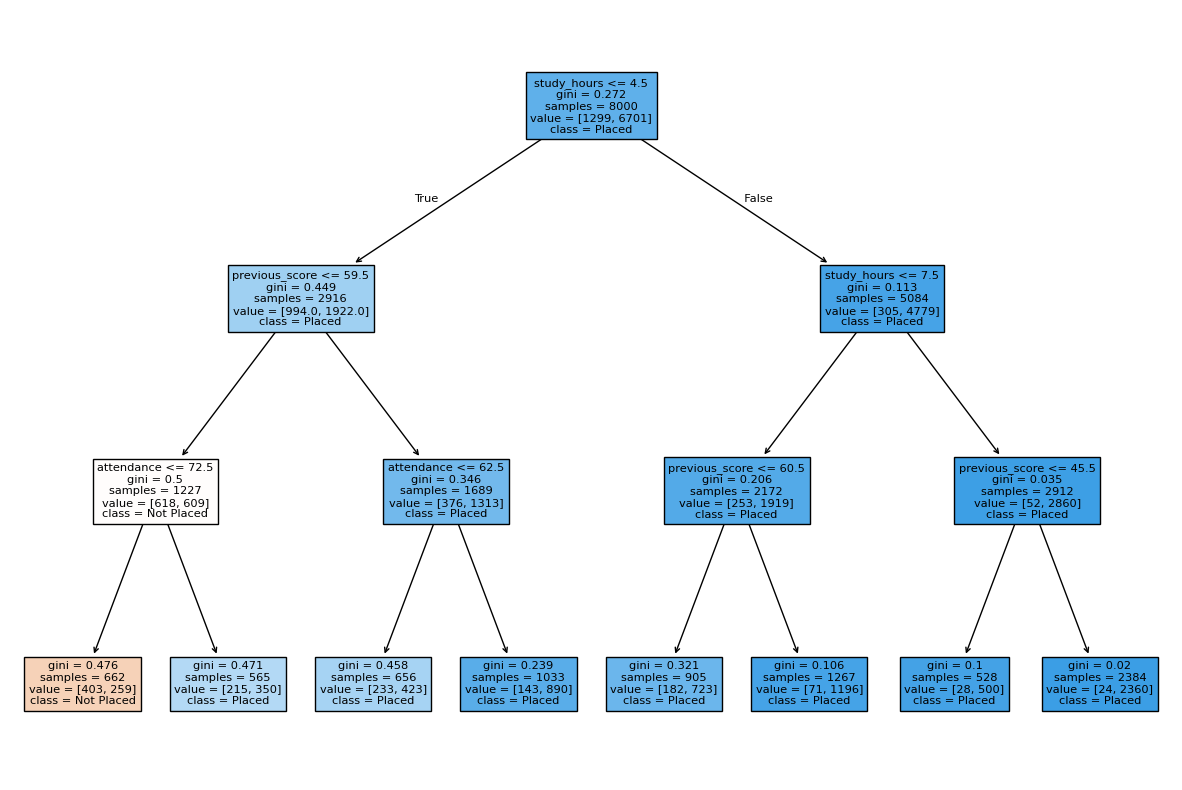

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(tree_model, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True)
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Random Forest മോഡൽ തയ്യാറാക്കുന്നു (100 മരങ്ങൾ)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. മോഡൽ ട്രെയിൻ ചെയ്യുന്നു
rf_model.fit(X_train, y_train)

# 3. പ്രവചനം നടത്തുന്നു
y_pred_rf = rf_model.predict(X_test)

# 4. റിസൾട്ട് പരിശോധിക്കുന്നു
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 83.35%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.52      0.40      0.45       345
           1       0.88      0.92      0.90      1655

    accuracy                           0.83      2000
   macro avg       0.70      0.66      0.68      2000
weighted avg       0.82      0.83      0.82      2000



In [27]:
import pickle

# മോഡലിനെ 'model.pkl' എന്ന പേരിലൊരു ഫയലായി സേവ് ചെയ്യുന്നു
with open('model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("✅ മോഡൽ വിജയകരമായി സേവ് ചെയ്തു!")

✅ മോഡൽ വിജയകരമായി സേവ് ചെയ്തു!


In [28]:
# requirements.txt ഫയൽ ഉണ്ടാക്കാൻ
requirements = """
pandas
numpy
scikit-learn
seaborn
matplotlib
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')